# Test line ratios

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
from lmfit import minimize, Parameters
from astropy.io import fits
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 

In [2]:
J2212 = pd.read_csv('/home/benjamin/Documents/analogs/specs/final_spec/J2212.csv')
wave = J2212['wave'].to_numpy()
flux = J2212['flux'].to_numpy()
noise = J2212['noise'].to_numpy()

In [3]:
class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# [NII]6548 + Ha + [NII]6584
select = (wave > 7650) * (wave < 7800)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], noise[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5650) * (wave < 5950)
oiii_hb = SpecPiece('oiii+hb', wave[select], flux[select], noise[select])

# [NII]6548 + H$\alpha$ + [NII]6584

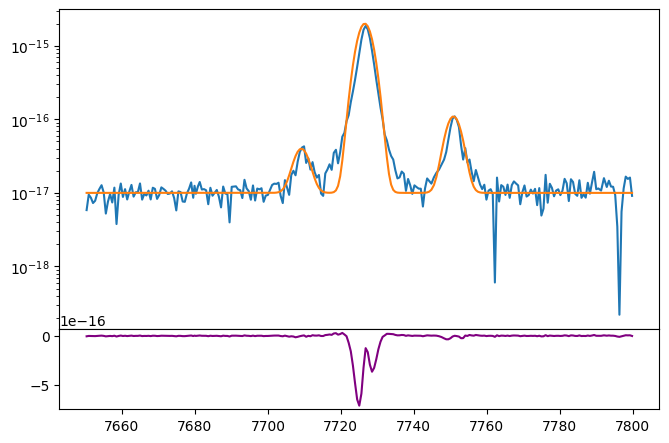

In [4]:
# Search for good initial guess
%matplotlib inline
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)

ha_wav = 6564.614
niib_wav = 6549.86
niia_wav = 6585.27
bkg = 1e-17

ha = gaussian(ha_nii.wavelength, 1e-14, ha_wav, z=0.177, sigma = 2)
niib = gaussian(ha_nii.wavelength, 1e-14 * 0.015, niib_wav, z=0.177, sigma = 2)
niia = gaussian(ha_nii.wavelength, 1e-14 * 0.05, niia_wav, z=0.177, sigma = 2)

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia)
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [5]:
params_ha_nii = Parameters()

params_ha_nii.add('z', value=0.177)
params_ha_nii.add('sigma', value=2, min=0.)
params_ha_nii.add('Ha_flux', value=1e-14, min=0.)
params_ha_nii.add('Niib_to_Ha', value=0.015, min=0., max=1.)
params_ha_nii.add('Niia_to_Ha', value=0.045, min=0., max=1.)
params_ha_nii.add('bkg', value=1e-17, min=0.)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    ha_wav = 6564.614
    niib_wav = 6549.86
    niia_wav = 6585.27
    
    z = params_ha_nii['z']
    sigma = params_ha_nii['sigma']
    ha_flux = params_ha_nii['Ha_flux']
    niia_flux = ha_flux * params_ha_nii['Niia_to_Ha']
    niib_flux = ha_flux * params_ha_nii['Niib_to_Ha']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    model = gaussian(x, niib_flux, niib_wav, z, sigma) + gaussian(x, ha_flux, ha_wav, z, sigma) + gaussian(x, niia_flux, niia_wav, z, sigma)
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [6]:
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10,
                     workers=12, nwalkers=75)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 138.78it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 32.94343085 112.55257018  62.3220403   37.70021667  46.21963317
  43.98218738]


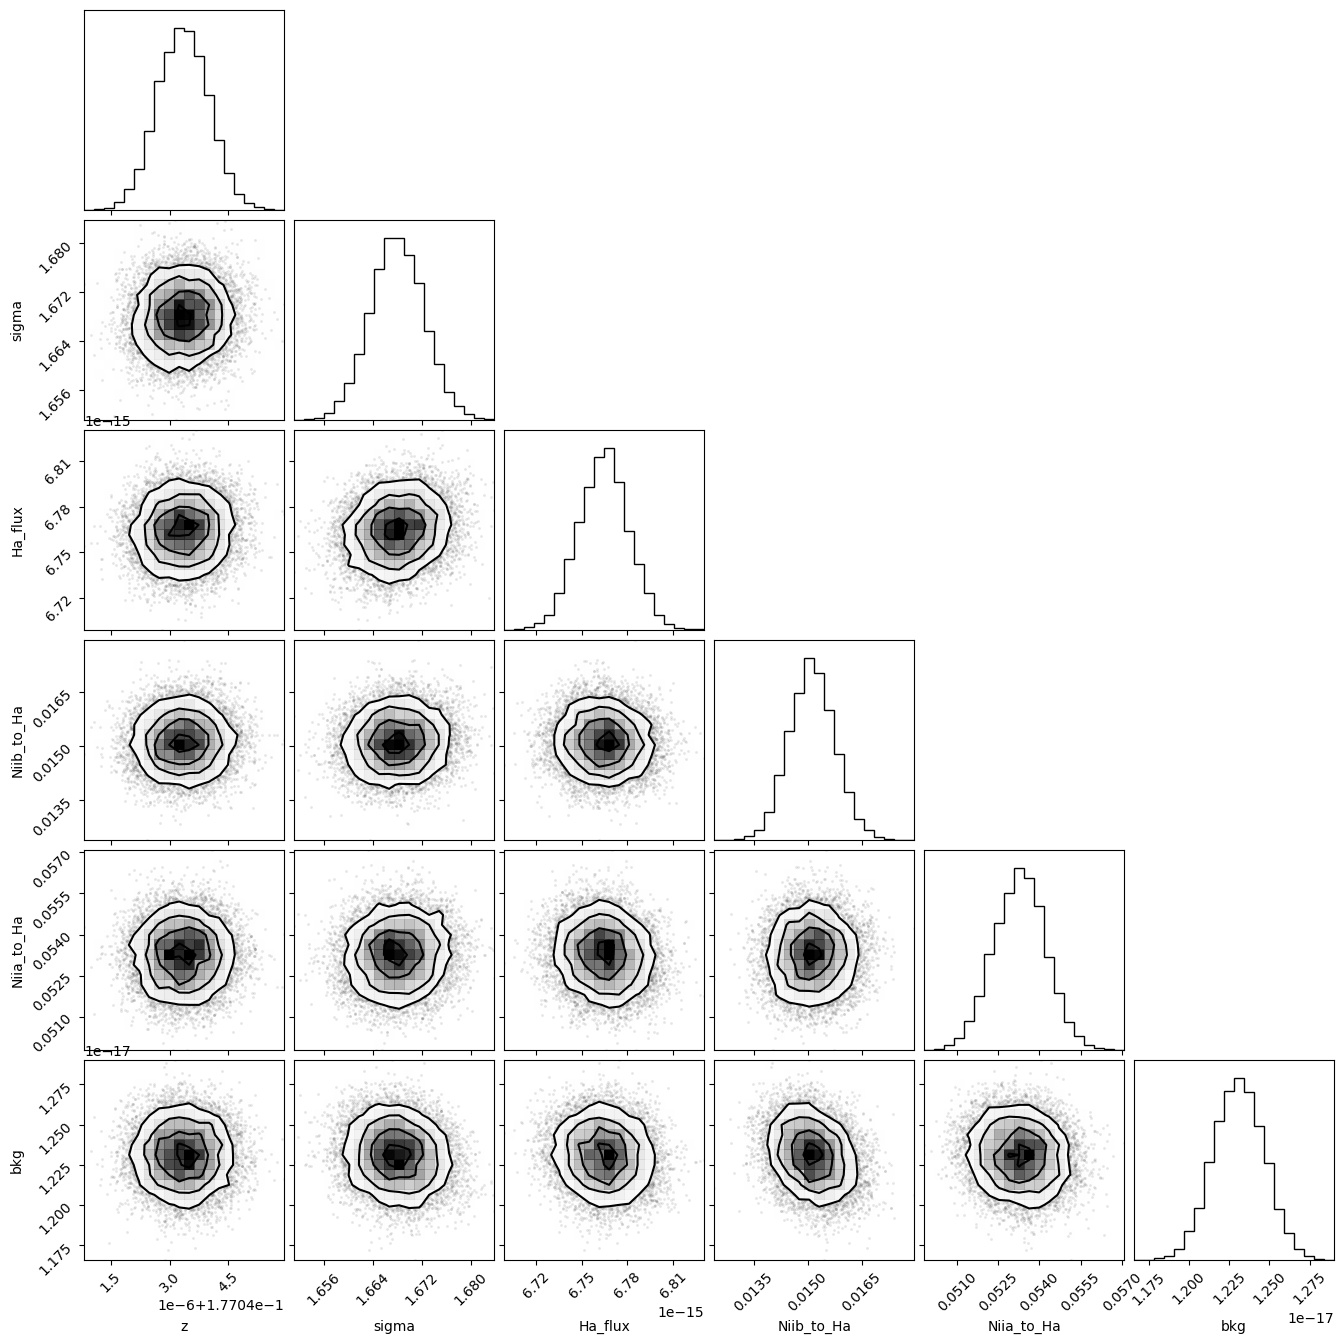

In [7]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [8]:
out_ha_nii

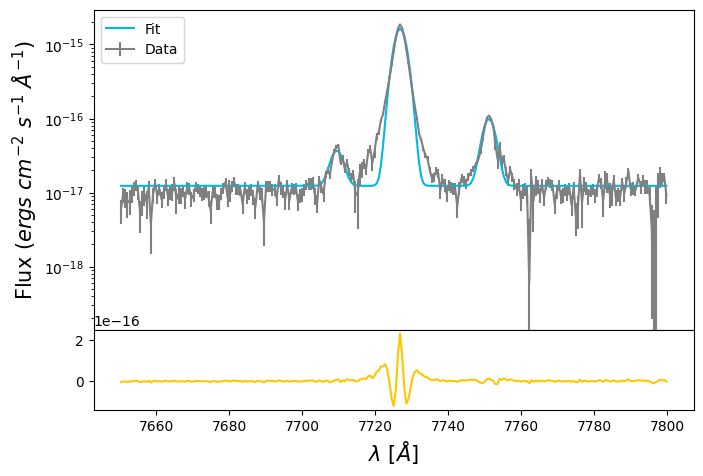

In [9]:
ha_flux = out_ha_nii.flatchain.Ha_flux.mean()
ha_std = out_ha_nii.flatchain.Ha_flux.std()

niia_flux = (ha_flux * out_ha_nii.flatchain.Niia_to_Ha).mean()
niia_std = (ha_flux * out_ha_nii.flatchain.Niia_to_Ha).std()

niib_flux = (ha_flux * out_ha_nii.flatchain.Niib_to_Ha).mean()
niib_std = (ha_flux * out_ha_nii.flatchain.Niib_to_Ha).std()

bkg_na_nii = out_ha_nii.flatchain.bkg.mean()
z_ha_nii = out_ha_nii.flatchain.z.mean()
sigma_ha_nii = out_ha_nii.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.errorbar(ha_nii.wavelength, ha_nii.flux, ha_nii.noise,
            color='gray', markersize=2, label='Data')

ha = gaussian(ha_nii.wavelength, ha_flux, ha_wav, z_ha_nii, sigma_ha_nii)
niia = gaussian(ha_nii.wavelength, niia_flux, niia_wav, z_ha_nii, sigma_ha_nii)
niib = gaussian(ha_nii.wavelength, niib_flux, niib_wav, z_ha_nii, sigma_ha_nii)

ax.plot(ha_nii.wavelength, bkg_na_nii + niia + ha + niib, color=c[0], label='Fit')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg_na_nii - niia - ha - niib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
#ax.text(x=7008, y=1.5e-13, s=r'[NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584',
#       fontsize=15)
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

# H$\beta$ + [OIII]4959 + [OIII]5007

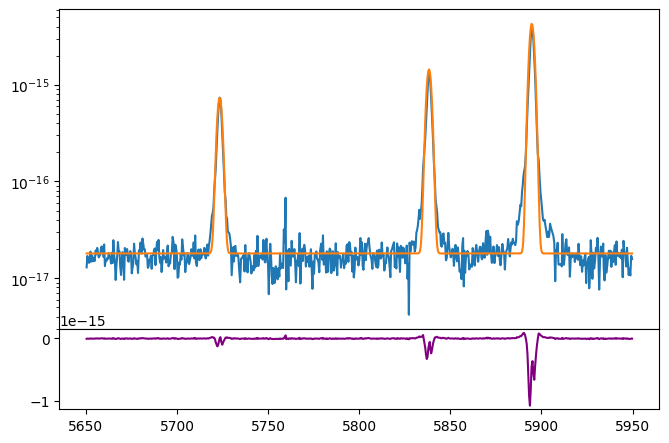

In [10]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hb.wavelength, oiii_hb.flux)

oiiia_wav = 5008.239
oiiib_wav = 4960.295
hb_wav = 4862.721
bkg = 1.8e-17

hb = gaussian(oiii_hb.wavelength, 1.4e-14 * 1/6, hb_wav, z=0.177, sigma=1.3)
oiiib = gaussian(oiii_hb.wavelength, 1.4e-14 * 1/3, oiiib_wav, z=0.177, sigma=1.3)
oiiia = gaussian(oiii_hb.wavelength, 1.4e-14, oiiia_wav, z=0.177, sigma=1.3)

ax.plot(oiii_hb.wavelength, bkg + hb + oiiib + oiiia)
ax1.plot(oiii_hb.wavelength, oiii_hb.flux - bkg - hb - oiiib - oiiia, color='purple')
ax.set_yscale('log')

In [11]:
params_oiii_hb = Parameters()

params_oiii_hb.add('z', value=0.177)
params_oiii_hb.add('sigma', value=1.3, min=0.)
params_oiii_hb.add('Oiiia_flux', value=1.4e-14, min=0.)
params_oiii_hb.add('Oiiib_to_Oiiia', value=1/3, min=0., max=1.)
params_oiii_hb.add('Hb_to_Oiiia', value=1/6, min=0., max=1.)
params_oiii_hb.add('bkg', value=1.8e-17, min=0.)

def residual_oiii_hb(params_oiii_hb, x, data, uncertainty):
    oiiia_wav = 5008.239
    oiiib_wav = 4960.295
    hb_wav = 4862.721
    
    z = params_oiii_hb['z']
    sigma = params_oiii_hb['sigma']
    oiiia_flux = params_oiii_hb['Oiiia_flux']
    oiiib_flux = oiiia_flux * params_oiii_hb['Oiiib_to_Oiiia']
    hb_flux = oiiia_flux * params_oiii_hb['Hb_to_Oiiia']
    
    bkg_oiii_hb = params_oiii_hb['bkg']
    
    x = oiii_hb.wavelength
    model_oiii_hb = gaussian(x, oiiia_flux, oiiia_wav, z, sigma) + gaussian(x, oiiib_flux, oiiib_wav, z, sigma)  + gaussian(x, hb_flux, hb_wav, z, sigma)
    
    return (model_oiii_hb + bkg_oiii_hb - oiii_hb.flux) / oiii_hb.noise

In [12]:
out_oiii_hb = minimize(residual_oiii_hb, params_oiii_hb, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10,
                      workers=12, nwalkers=75)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 114.79it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 27.16771119 105.15630148  83.39847123  21.46269674 183.17922715
  84.25467711]


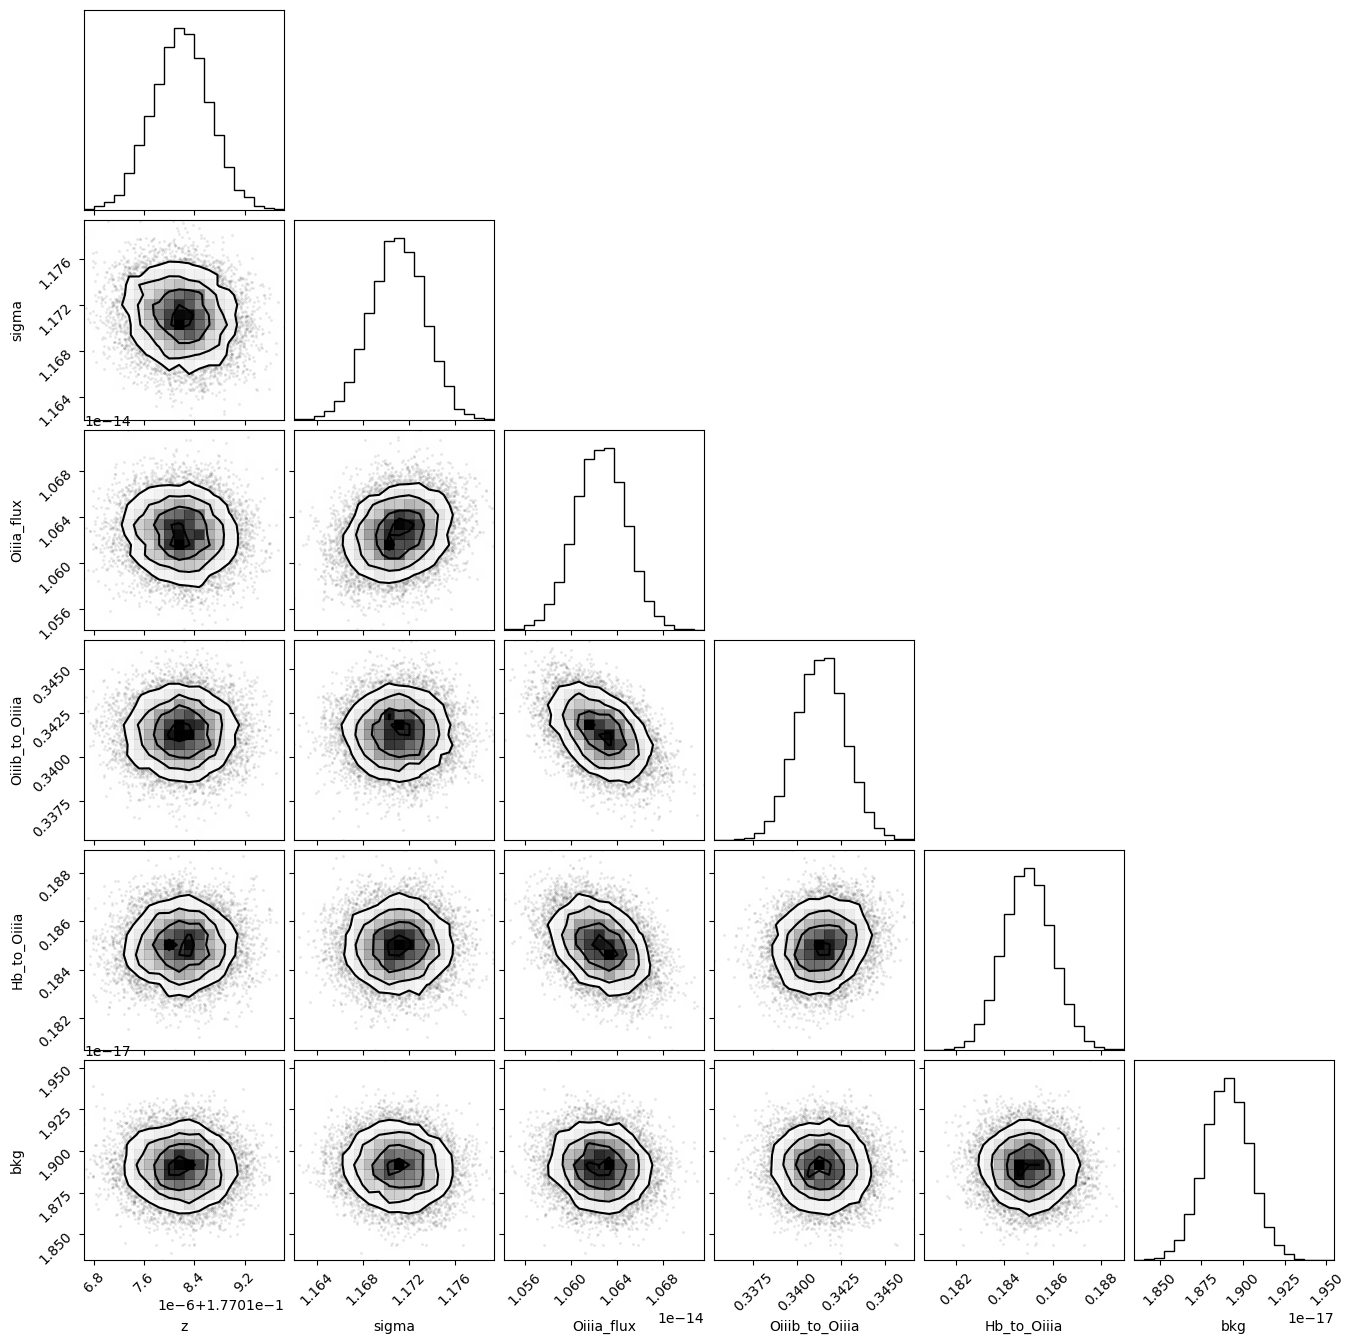

In [13]:
corner.corner(out_oiii_hb.flatchain, labels=out_oiii_hb.var_names);
#plt.savefig(fname='corner.jpg', bbox_inches='tight')

In [14]:
out_oiii_hb

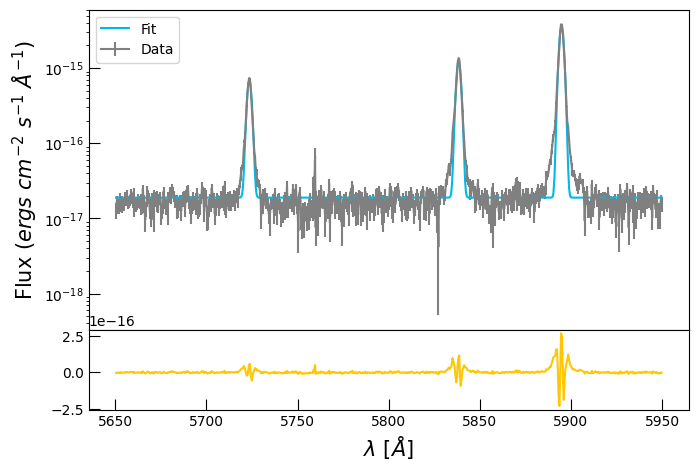

In [15]:
oiiia_flux = out_oiii_hb.flatchain.Oiiia_flux.mean()
oiiia_std = out_oiii_hb.flatchain.Oiiia_flux.std()

oiiib_flux = (oiiia_flux * out_oiii_hb.flatchain.Oiiib_to_Oiiia).mean()
oiiib_std = (oiiia_flux * out_oiii_hb.flatchain.Oiiib_to_Oiiia).std()

hb_flux = (oiiia_flux * out_oiii_hb.flatchain.Hb_to_Oiiia).mean()
hb_std = (oiiia_flux * out_oiii_hb.flatchain.Hb_to_Oiiia).std()

bkg_oiii_hb = out_oiii_hb.flatchain.bkg.mean()
z_oiii_hb = out_oiii_hb.flatchain.z.mean()
sigma_oiii_hb = out_oiii_hb.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.errorbar(oiii_hb.wavelength, oiii_hb.flux, oiii_hb.noise,
            color='gray', markersize=2, label='Data')

oiiia = gaussian(oiii_hb.wavelength, oiiia_flux, oiiia_wav, z_oiii_hb, sigma_oiii_hb)
oiiib = gaussian(oiii_hb.wavelength, oiiib_flux, oiiib_wav, z_oiii_hb, sigma_oiii_hb)
hb = gaussian(oiii_hb.wavelength, hb_flux, hb_wav, z_oiii_hb, sigma_oiii_hb)

ax.plot(oiii_hb.wavelength, bkg_oiii_hb + hb + oiiib + oiiia,
        color=c[0], label='Fit')
ax1.plot(oiii_hb.wavelength, oiii_hb.flux - bkg_oiii_hb - hb - oiiib - oiiia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.tick_params(axis='y', direction='in', length=8)
#ax1.set_yscale('log')
ax1.tick_params(axis='x', direction='in', length=8)
ax1.tick_params(axis='y', direction='in', length=8)
ax.set_xticks([]);
ax.legend(loc='upper left')
#ax.text(5200, 3.6e-13, s=r'H$\beta$ + [OIII]$\lambda$4959 + [OIII]$\lambda$5007',
#       fontsize=15);
#plt.savefig(fname='hb_oiii.svg', bbox_inches='tight')

In [16]:
import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy

ha = ufloat(ha_flux, ha_std)
niia = ufloat(niia_flux, niia_std)
niib = ufloat(niib_flux, niib_std)
oiiia = ufloat(oiiia_flux, oiiia_std)
oiiib = ufloat(oiiib_flux, oiiib_std)
hb = ufloat(hb_flux, hb_std)

In [17]:
ha

6.7645021038670764e-15+/-1.6478272515109393e-17

In [18]:
niia

3.604090915699258e-16+/-6.347245027980789e-18

In [19]:
oiiia

1.0626086383406573e-14+/-2.2047262679972947e-17

In [20]:
hb

1.965764717251243e-15+/-1.0744479378711155e-17